### Data profiling,Cleaning and Eda For Benin-malanville


In [38]:
# import necessary python libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
import seaborn as sns


In [39]:
# load the dataset
benin=pd.read_csv('../data/benin-malanville.csv')
benin.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


In [40]:
benin.dtypes# check what the datatypes of each columns are 

Timestamp         object
GHI              float64
DNI              float64
DHI              float64
ModA             float64
ModB             float64
Tamb             float64
RH               float64
WS               float64
WSgust           float64
WSstdev          float64
WD               float64
WDstdev          float64
BP                 int64
Cleaning           int64
Precipitation    float64
TModA            float64
TModB            float64
Comments         float64
dtype: object

###  Summery of  Statistics and Missing Value Report

In [41]:
# describe the data
benin.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
std,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN
min,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN


In [42]:
# check missing data
missing_values=benin.isna().sum()
missing_values


Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

In [43]:
total_rows=len(benin) # length of the dataset
total_rows

525600

In [44]:
# missing value percentage
missing_percentage=(missing_values/total_rows)*100
missing_percentage

Timestamp          0.0
GHI                0.0
DNI                0.0
DHI                0.0
ModA               0.0
ModB               0.0
Tamb               0.0
RH                 0.0
WS                 0.0
WSgust             0.0
WSstdev            0.0
WD                 0.0
WDstdev            0.0
BP                 0.0
Cleaning           0.0
Precipitation      0.0
TModA              0.0
TModB              0.0
Comments         100.0
dtype: float64

In [45]:
# printing columns with > 5% missing values
for col,percent in missing_percentage.items():
    if percent>5:
        print(f"{col}: {percent}%")

Comments: 100.0%


In [46]:
# let's have copy of the dataset
benin_cp=benin.copy()
benin_cp.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


In [47]:
# drop the columns that are not necessary for our analysis with >5% missing values
benin_cp=benin_cp.drop('Comments',axis=1)

In [48]:
benin_cp.columns

Index(['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS',
       'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation',
       'TModA', 'TModB'],
      dtype='object')

In [49]:
# important numerical columns list
num_cols=['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb']

In [50]:
oulire_flag = np.abs(zscore(benin_cp[num_cols])) 
outliers = (oulire_flag > 3).any(axis=1)
benin_cp['Outlires'] = outliers
benin_cp['Outlires'].value_counts()


Outlires
False    521771
True       3829
Name: count, dtype: int64

In [51]:
# plot boxplot for numeric cols
benin_cp.boxplot(num_cols,figsize=(12,8));





In [52]:
# export cleaned data
benin_cp.to_csv('../data/benin-malanville-cleaned.csv',index=False)


### Time Series Analysis

In [53]:
benin_cp.Timestamp

0         2021-08-09 00:01
1         2021-08-09 00:02
2         2021-08-09 00:03
3         2021-08-09 00:04
4         2021-08-09 00:05
                ...       
525595    2022-08-08 23:56
525596    2022-08-08 23:57
525597    2022-08-08 23:58
525598    2022-08-08 23:59
525599    2022-08-09 00:00
Name: Timestamp, Length: 525600, dtype: object

In [54]:
# convert Timestamp to datetime format
benin_cp['Timestamp']=pd.to_datetime(benin_cp['Timestamp'])
benin_cp.set_index('Timestamp',inplace=True)

In [55]:
benin_cp.head()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Outlires
Timestamp,,,,,,,,,,,,,,,,,,
2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,False
2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,False
2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,False
2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,False
2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,False


### Timestamp Plots


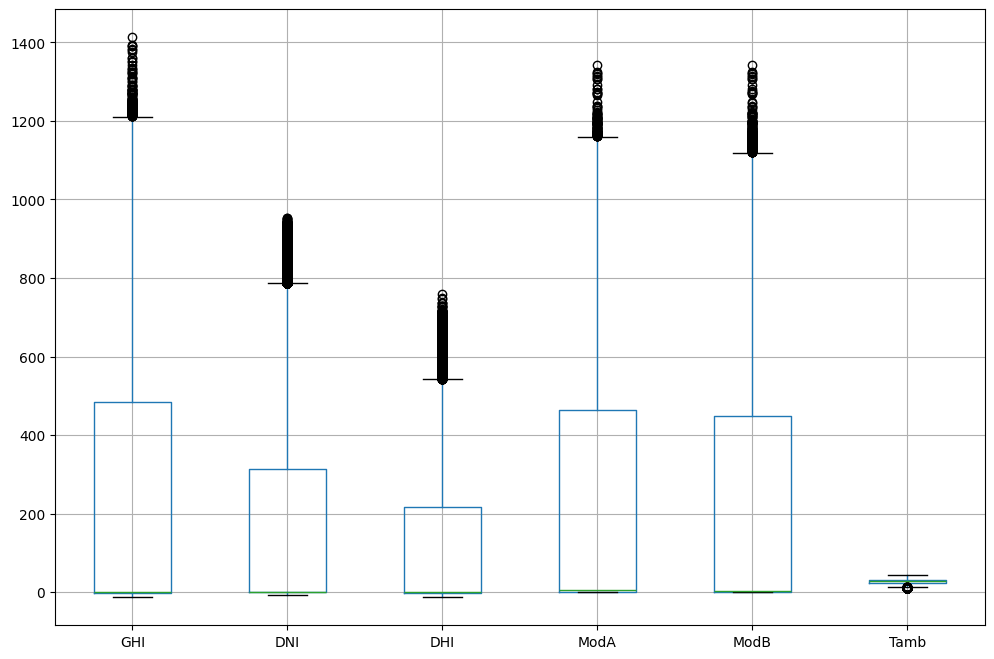

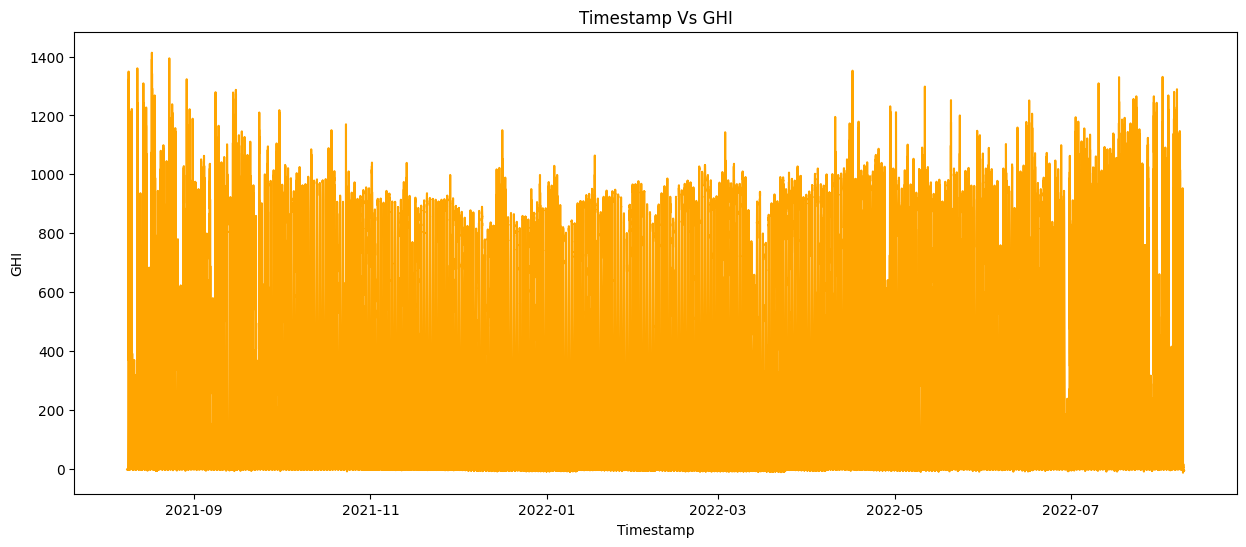

In [56]:
# Timestamp Vs GHI plot
plt.figure(figsize=(15,6))
plt.plot(benin_cp.index,benin_cp["GHI"],color='orange')
plt.title('Timestamp Vs GHI')
plt.xlabel('Timestamp')
plt.ylabel('GHI')
plt.show()


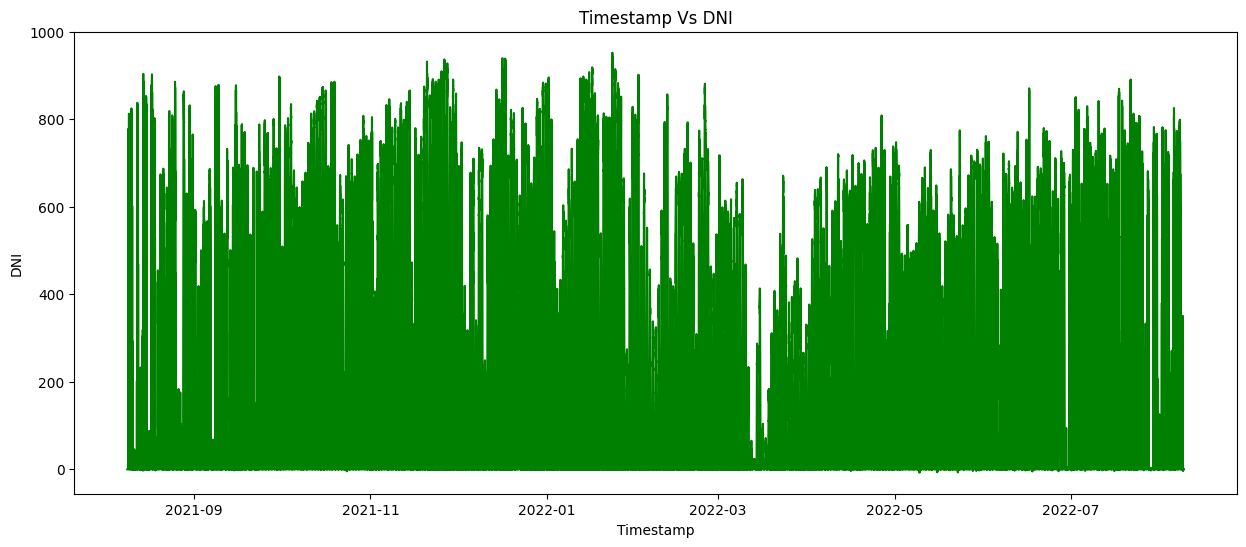

In [57]:
# Timestamp vs DNI plot
plt.figure(figsize=(15,6))
plt.plot(benin_cp.index,benin_cp["DNI"],color='green')
plt.title('Timestamp Vs DNI')
plt.xlabel('Timestamp')
plt.ylabel('DNI')
plt.show()


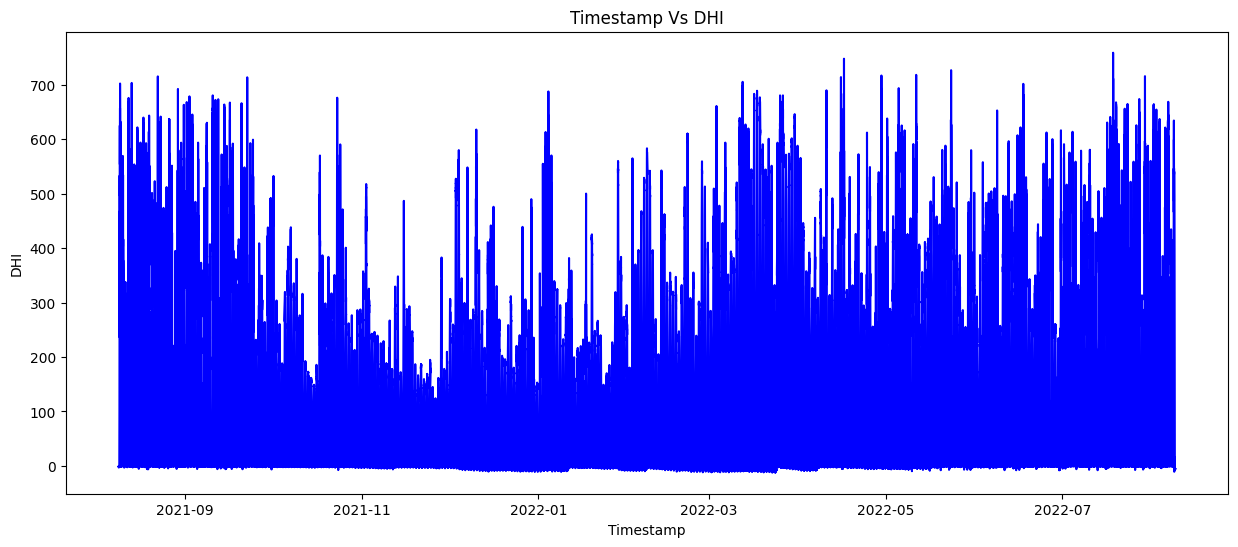

In [58]:
# Timestamp vs DHI plot
plt.figure(figsize=(15,6))
plt.plot(benin_cp.index,benin_cp["DHI"],color='blue')
plt.title('Timestamp Vs DHI')
plt.xlabel('Timestamp')
plt.ylabel('DHI')
plt.show()

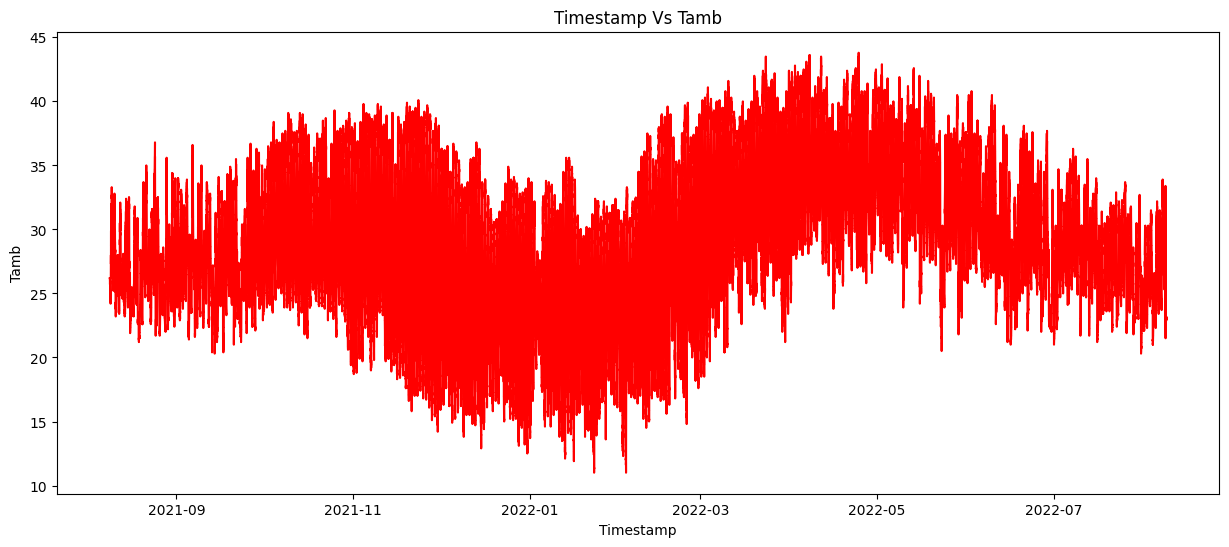

In [59]:
# Timestamp vs Tamb plot
plt.figure(figsize=(15,6))
plt.plot(benin_cp.index,benin_cp["Tamb"],color='red')
plt.title('Timestamp Vs Tamb')
plt.xlabel('Timestamp')
plt.ylabel('Tamb')
plt.show()

In [60]:
# obsernve patterns in months
benin_cp['Month']=benin_cp.index.month # extract month from timestamp
# compute monthly average for numeric columns
monthly_avg=benin_cp.groupby('Month')[num_cols].mean()
monthly_avg


,GHI,DNI,DHI,ModA,ModB,Tamb
Month,,,,,,
1,236.127899,223.528044,85.099924,258.110289,242.310712,23.328141
2,261.717381,183.575208,123.602111,271.789606,251.921992,25.814008
3,246.681272,101.955347,159.999859,243.236362,222.428784,31.699034
4,268.759785,160.630734,134.699329,250.338377,243.634081,33.773639
5,256.238629,147.091293,135.635515,228.603017,224.995822,32.495177
6,232.787537,144.552778,118.637521,202.095769,200.385405,29.332551
7,222.814444,130.135970,121.314397,196.639830,195.213345,27.329886
8,200.085029,99.048864,122.297982,185.433253,185.079034,26.489048
9,222.887431,128.179900,122.124169,214.701181,214.852618,27.157532


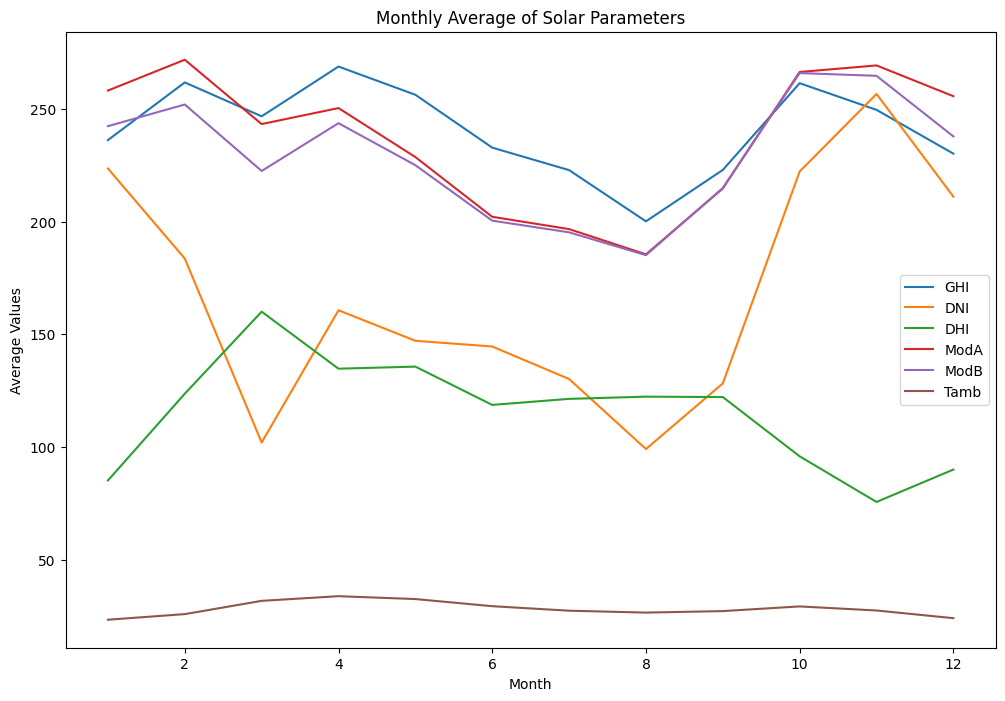

In [61]:
# show monthly pattens plots
monthly_avg.plot(figsize=(12,8))
plt.title('Monthly Average of Solar Parameters')
plt.xlabel('Month')
plt.ylabel('Average Values')
plt.show()

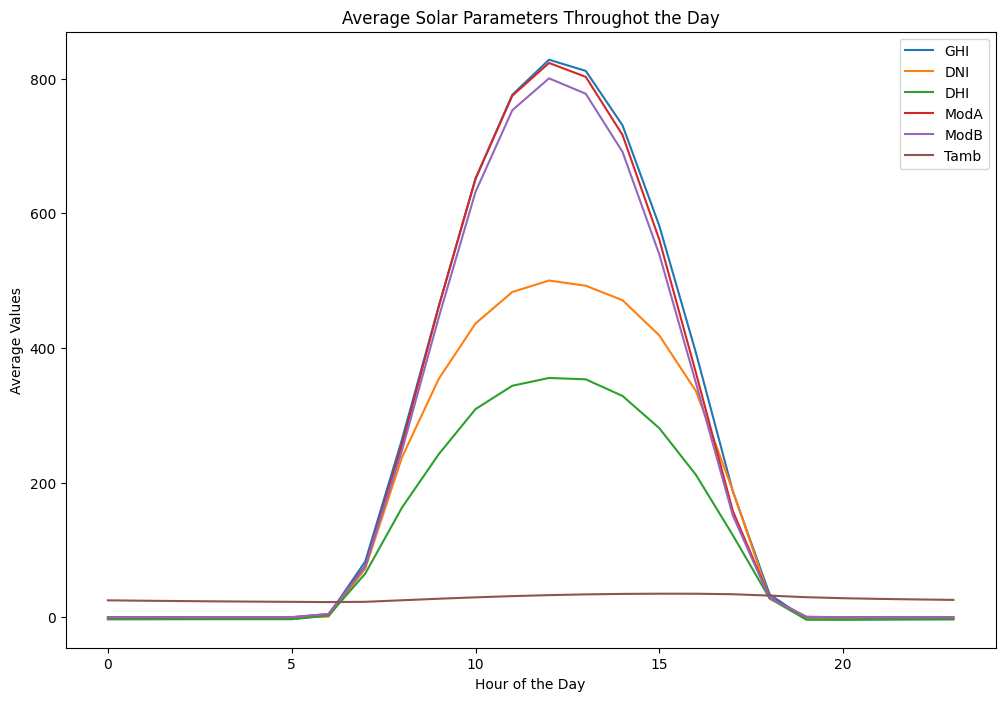

In [62]:
# Trends throughout the day
benin_cp['Hour']=benin_cp.index.hour # extraxt hour from timestamp
daily_avg=benin_cp.groupby('Hour')[num_cols].mean()
daily_avg.plot(figsize=(12,8))
plt.title('Average Solar Parameters Throughot the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Values')
plt.show()


In [63]:
# Detect anomalies in GHI using rolling mean and std deviation
ghi_mean,ghi_std=benin_cp['GHI'].mean(),benin_cp['GHI'].std()
# detect anomalies
benin_cp['GHI_Anomaly']=((benin_cp['GHI']> (ghi_mean + 3*ghi_std)) | (benin_cp['GHI']< (ghi_mean - 3*ghi_std)))
benin_cp['GHI_Anomaly'].value_counts()


GHI_Anomaly
False    525511
True         89
Name: count, dtype: int64

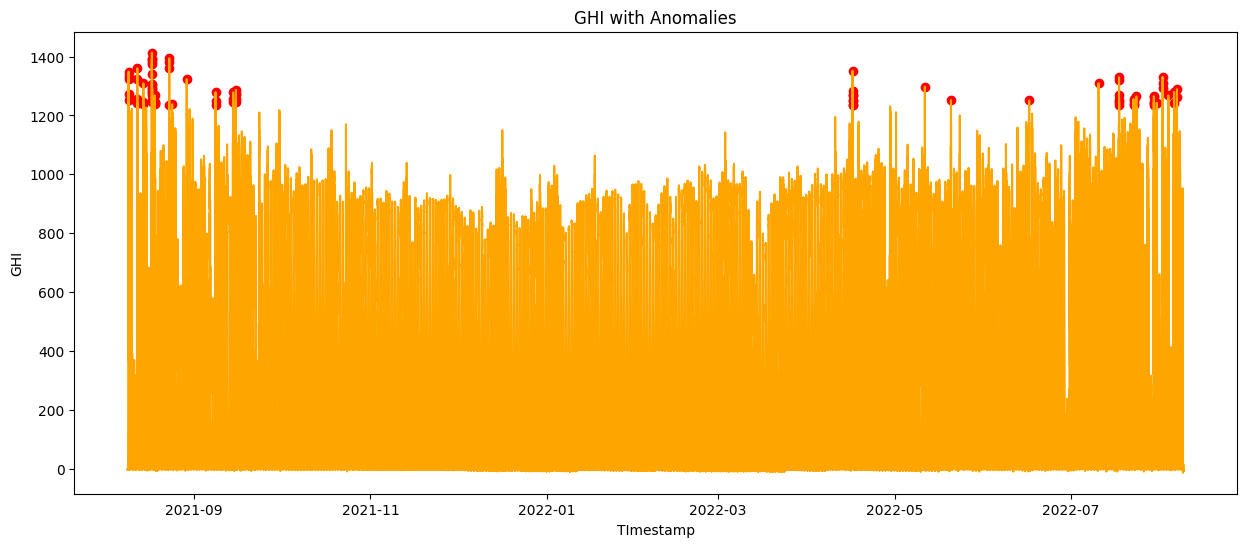

In [64]:
# plot anomalies
plt.figure(figsize=(15,6))
plt.plot(benin_cp.index,benin_cp["GHI"],label='GHI',color='orange')
plt.scatter(
    benin_cp[benin_cp['GHI_Anomaly']].index, 
    benin_cp[benin_cp['GHI_Anomaly']]['GHI'],
    color='red',label='Anomalies')
plt.title('GHI with Anomalies')
plt.xlabel('TImestamp')
plt.ylabel('GHI')
plt.show()



### Cleaning Impact

In [65]:
benin_cp.ModA.value_counts()

ModA
0.0       245543
0.1         3003
0.2         1338
0.3          912
0.4          705
           ...  
1091.8         1
1137.1         1
1147.2         1
1149.2         1
1068.6         1
Name: count, Length: 10755, dtype: int64

In [66]:
benin_cp.ModA.describe()

count    525600.000000
mean        236.589496
std         326.894859
min           0.000000
25%           0.000000
50%           4.500000
75%         463.700000
max        1342.300000
Name: ModA, dtype: float64

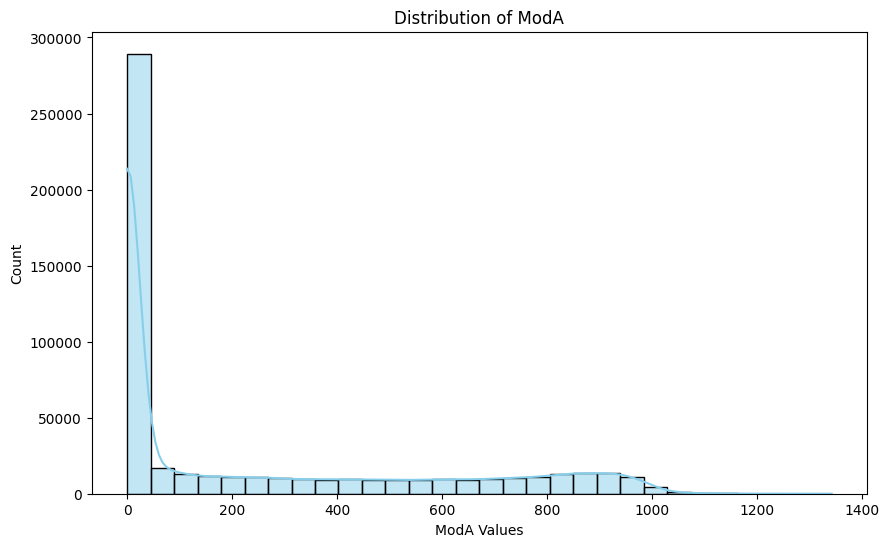

In [67]:
#graph to show distribution of ModA
plt.figure(figsize=(10,6))
sns.histplot(benin_cp['ModA'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of ModA')
plt.xlabel('ModA Values')
plt.show();

In [74]:
# compute mean and std of ModA
moda_mean=benin_cp['ModA'].mean()
moda_std=benin_cp['ModA'].std()
#Flag to identify outliers in ModA
benin_cp['Cleaning'] = 'Pre'  # default value
benin_cp.loc[(benin_cp['ModA']> moda_mean + 3*moda_std) | (benin_cp['ModA']< moda_mean -3*moda_std), 'Cleaning']= 'Post'
benin_cp.loc[benin_cp['ModA'] == 0, 'Cleaning'] = 'Post'
# clean ModA 
upper=moda_mean + 3*moda_std
lower=moda_mean - 3*moda_std
benin_cp['ModA_clean']=benin_cp['ModA'].clip(lower,upper)
# group by cleaning status and get average ModA values
avg_moda=benin_cp.groupby('Cleaning')[['ModA','ModA_clean']].mean()
print(avg_moda)



                ModA  ModA_clean
Cleaning                        
Post        0.139547    0.133837
Pre       443.942330  443.942330


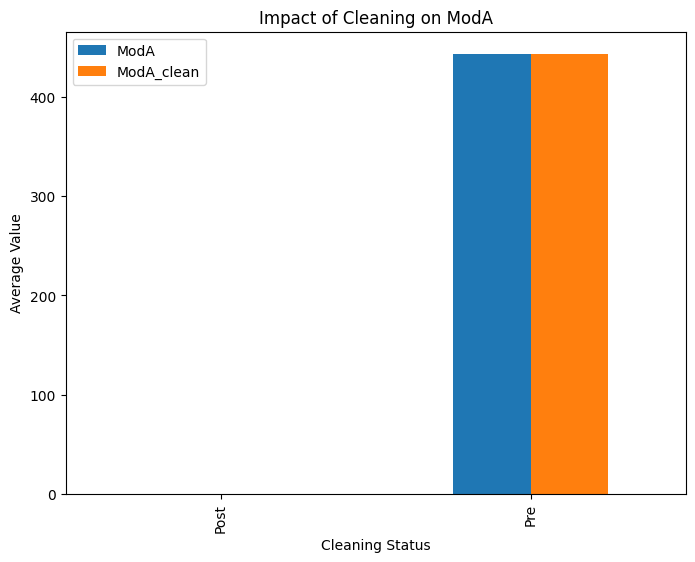

In [75]:
avg_moda.plot(kind='bar', figsize=(8,6)) # plot to show impact of cleaning on ModA
plt.title('Impact of Cleaning on ModA')
plt.ylabel('Average Value')
plt.xlabel('Cleaning Status')
plt.show()

In [69]:
benin_cp.ModB.describe()

count    525600.000000
mean        228.883576
std         316.536515
min           0.000000
25%           0.000000
50%           4.300000
75%         447.900000
max        1342.300000
Name: ModB, dtype: float64

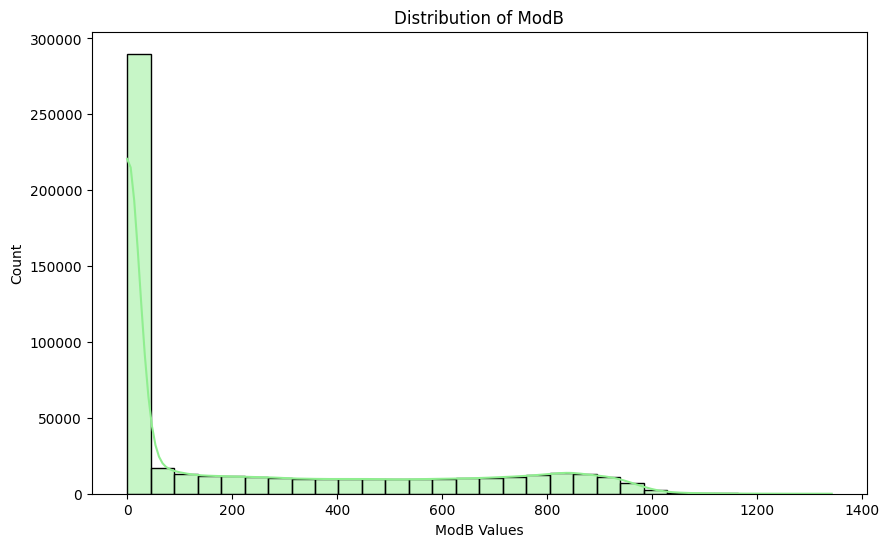

In [70]:
# graph to show distribution of ModB
plt.figure(figsize=(10,6))
sns.histplot(benin_cp['ModB'], bins=30, kde=True, color='lightgreen')
plt.title('Distribution of ModB')
plt.xlabel('ModB Values')
plt.show();

In [71]:
# compute mean and std of ModA
modb_mean=benin_cp['ModB'].mean()
modb_std=benin_cp['ModB'].std()
#Flag to identify outliers in ModA
benin_cp['Cleaning'] = 'Pre'  # default value
benin_cp.loc[(benin_cp['ModB']> modb_mean + 3*modb_std) | (benin_cp['ModB']< modb_mean -3*modb_std), 'Cleaning']= 'Post'
benin_cp.loc[benin_cp['ModB'] == 0, 'Cleaning'] = 'Post'

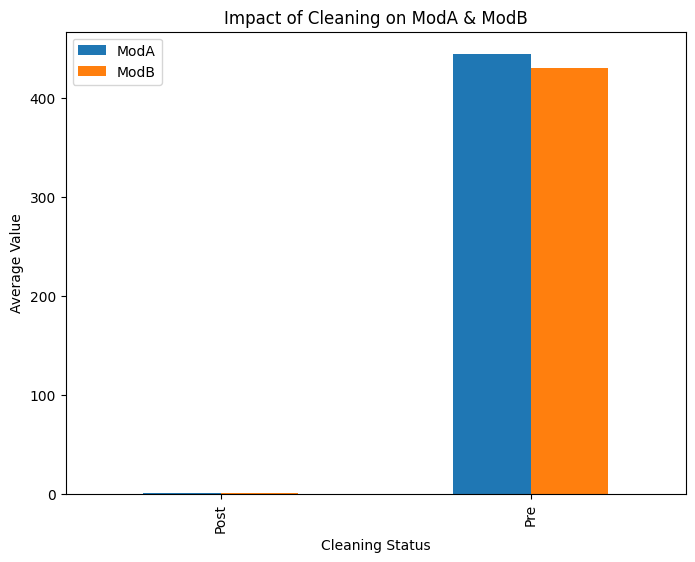

In [72]:
# show the cleaning results with graph
avg_values = benin_cp.groupby('Cleaning')[['ModA','ModB']].mean()
avg_values.plot(kind='bar', figsize=(8,6))
plt.title('Impact of Cleaning on ModA & ModB')
plt.ylabel('Average Value')
plt.xlabel('Cleaning Status')
plt.show()


### Correlation & Relationship Analysis

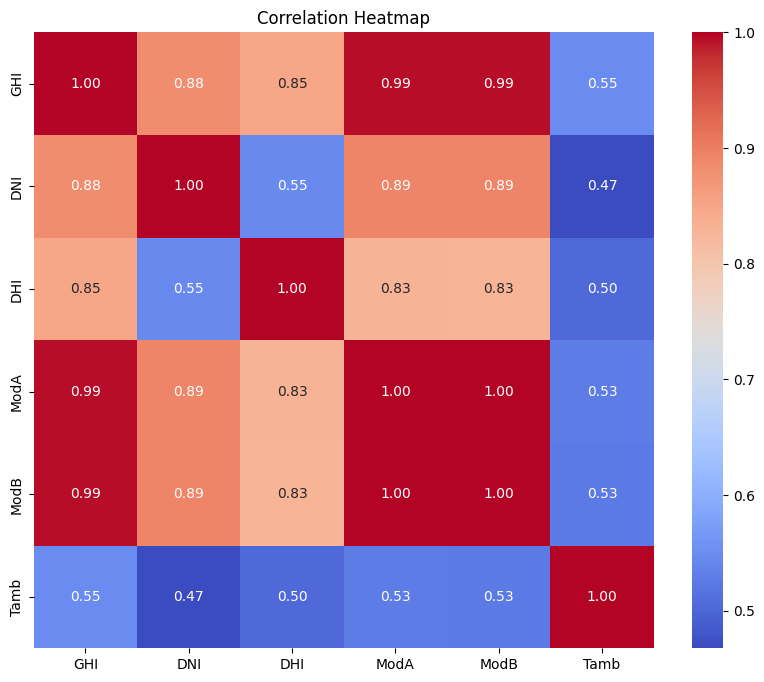

In [76]:
# draw correlation heatmap for numerical columns
plt.figure(figsize=(10,8))
corr_matrix=benin_cp[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

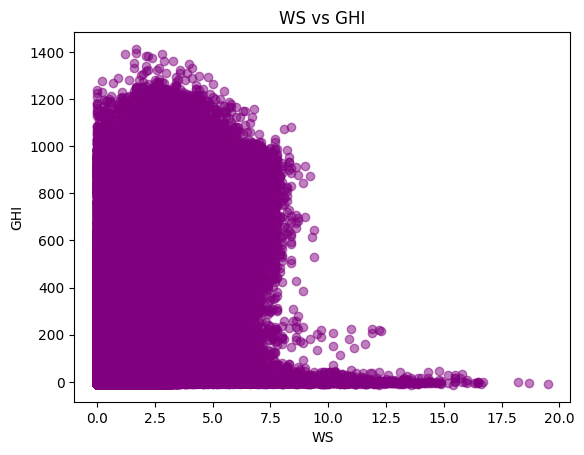

In [78]:
# scatter plot WS vs GHI
plt.scatter(benin_cp['WS'], benin_cp['GHI'], alpha=0.5, color='purple')
plt.title('WS vs GHI')
plt.xlabel('WS')
plt.ylabel('GHI')
plt.show()

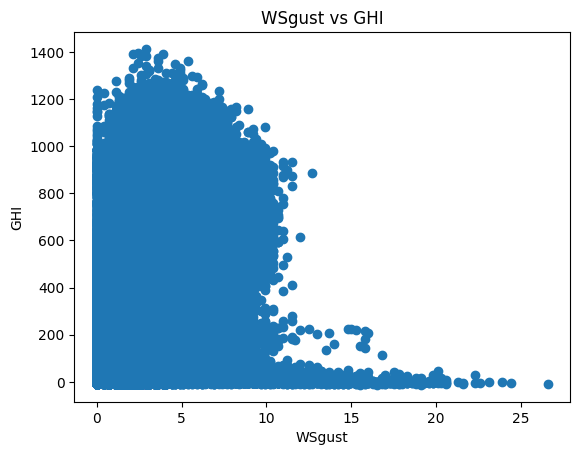

In [79]:
# scatter plot berween WSgust vs GHI
plt.scatter(benin_cp['WSgust'], benin_cp['GHI'])
plt.title('WSgust vs GHI')
plt.xlabel('WSgust')
plt.ylabel('GHI')
plt.show()

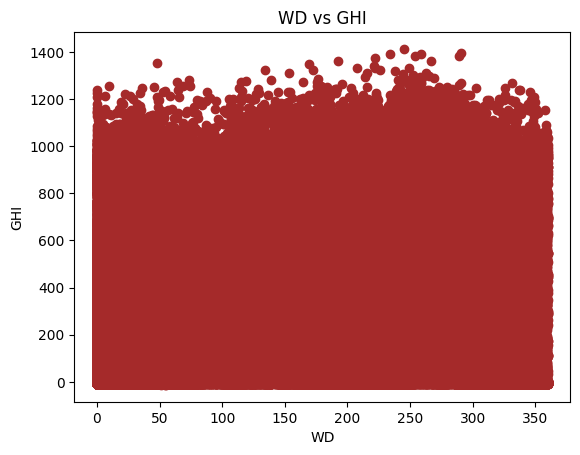

In [80]:
# scatter plot between WD and GHI
plt.scatter(benin_cp['WD'], benin_cp['GHI'], color='brown')
plt.title('WD vs GHI')
plt.xlabel('WD')
plt.ylabel('GHI')
plt.show()